
# Amazon Churn — ONE-SHOT Model Benchmark (NO CV) — Set A only
## Models:
### Logistic, Decision Tree, Random Forest, AdaBoost, GradientBoost, XGBoost, CatBoost, LightGBM, SVM

## Output:
### Single leaderboard with Train/Test AUC + gaps + classification metrics

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

# if working with XGBooste, lightgbm in DataBricks rum this before importing library
# %pip install xgboost
# %pip install catboost
# %pip install lightgbm
# dbutils.library.restartPython()


from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


# CONFIG

In [0]:
## CONFIG

TARGET_SCHEMA = "workspace.amazon"
TARGET_TABLE  = "amazon_cust"
TARGET_COL    = "churn_90d"

TEST_SIZE = 0.30
SEED = 42
THRESHOLD = 0.50

# Faster CV
N_SPLITS = 3

FEATURES_A = [
    "city_tier", "acquisition_channel", "prime_active_flag",
    "orders_4w", "spend_4w", "sessions_4w",
    "pct_orders_with_coupon_4w", "avg_discount_pct_4w",
    "returns_12w", "tickets_12w", "avg_csat_12w",
    "days_since_last_order"
]


# LOAD

In [0]:
df = spark.table(f"{TARGET_SCHEMA}.{TARGET_TABLE}").toPandas()  # noqa: F821
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found!"

keep_cols = [c for c in FEATURES_A if c in df.columns]
X = df[keep_cols].copy()
y = df[TARGET_COL].astype(int).values

print("Rows:", len(df), "| Features:", X.shape[1], "| Churn rate:", f"{df[TARGET_COL].mean():.3%}")

Rows: 100000 | Features: 12 | Churn rate: 42.776%


# PREPROCESS

In [0]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

def prob_to_class(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (p >= threshold).astype(int)

def eval_one(model_name: str, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    p_tr = pipe.predict_proba(X_train)[:, 1]
    p_te = pipe.predict_proba(X_test)[:, 1]

    yhat_tr = prob_to_class(p_tr, THRESHOLD)
    yhat_te = prob_to_class(p_te, THRESHOLD)

    train_auc = roc_auc_score(y_train, p_tr)
    test_auc  = roc_auc_score(y_test, p_te)

    train_acc = accuracy_score(y_train, yhat_tr)
    test_acc  = accuracy_score(y_test, yhat_te)

    return {
        "model": model_name,
        "train_auc": round(train_auc, 3),
        "test_auc": round(test_auc, 3),
        "auc_gap": round(train_auc - test_auc, 3),
        "train_acc": round(train_acc, 3),
        "test_acc": round(test_acc, 3),
        "acc_gap": round(train_acc - test_acc, 3),
        "test_precision": round(precision_score(y_test, yhat_te, zero_division=0), 3),
        "test_recall": round(recall_score(y_test, yhat_te, zero_division=0), 3),
        "test_f1": round(f1_score(y_test, yhat_te, zero_division=0), 3),
    }

# -----------------------------
# SPLIT ONCE (same split for all models)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

# MODELS (reasonable defaults; not too heavy)

In [0]:
## MODELS (Reduced estimators)

models = [
    ("Logistic Regression", LogisticRegression(max_iter=200, solver="lbfgs")),
    ('KNN',KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2)),
    ('BernoulliNB', BernoulliNB(alpha=1.0, force_alpha=True, binarize=0.0, fit_prior=True)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=7, min_samples_leaf=80, random_state=SEED)),
    ("Random Forest", RandomForestClassifier(n_estimators=120, min_samples_leaf=50, n_jobs=-1, random_state=SEED)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=80, learning_rate=0.05, random_state=SEED)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=120, learning_rate=0.05, max_depth=3, random_state=SEED)),
    ("XGBoost", XGBClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=4,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric="logloss", random_state=SEED
    )),
    ("CatBoost", CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=4,
        verbose=0, random_state=SEED
    )),
    ("LightGBM", LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        num_leaves=31, subsample=0.85, colsample_bytree=0.85,
        random_state=SEED, n_jobs=-1
    )),
]



# RUN

In [0]:
rows = []
for name, model in models:
    print(f"Running: {name}")
    rows.append(eval_one(name, model, X_train, X_test, y_train, y_test))

leaderboard = pd.DataFrame(rows).sort_values(["test_auc", "auc_gap"], ascending=[False, True])

print("\n" + "=" * 110)
print("ONE-SHOT LEADERBOARD (NO CV) — Set A | sorted by TEST AUC then lower overfit gap")
print("=" * 110)
print(leaderboard.to_string(index=False))

Running: Logistic Regression


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Running: KNN
Running: BernoulliNB
Running: Decision Tree
Running: Random Forest
Running: AdaBoost
Running: Gradient Boosting
Running: XGBoost
Running: CatBoost
Running: LightGBM
[LightGBM] [Info] Number of positive: 29943, number of negative: 40057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1219
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 284
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.427757 -> initscore=-0.291008
[LightGBM] [Info] Start training from score -0.291008


/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



ONE-SHOT LEADERBOARD (NO CV) — Set A | sorted by TEST AUC then lower overfit gap
              model  train_auc  test_auc  auc_gap  train_acc  test_acc  acc_gap  test_precision  test_recall  test_f1
           LightGBM      0.733     0.704    0.029      0.679     0.664    0.015           0.640        0.493    0.557
Logistic Regression      0.875     0.701    0.174      0.784     0.661    0.124           0.627        0.510    0.562
           CatBoost      0.703     0.699    0.004      0.659     0.660   -0.001           0.639        0.472    0.543
            XGBoost      0.711     0.699    0.012      0.664     0.660    0.004           0.637        0.477    0.545
  Gradient Boosting      0.704     0.697    0.006      0.659     0.658    0.001           0.636        0.470    0.540
      Decision Tree      0.696     0.684    0.012      0.655     0.647    0.008           0.618        0.460    0.527
           AdaBoost      0.681     0.680    0.001      0.640     0.642   -0.001           0.

# SHAP EXTENSION (works best for tree/boosting models)
## Adds:

### Fits ONE chosen best model (or any you specify)
### Builds transformed feature matrix + feature names
### Computes SHAP values (TreeExplainer)
## Produces:
- ### SHAP Summary Plot (bar)
- ### SHAP Summary Plot (beeswarm)
- ### Top drivers table
## Notes:
### Recommended: run SHAP for the best TREE model: XGBoost / LightGBM / CatBoost / RandomForest
### Option B: auto pick best from leaderboard among tree models

In [0]:
# Option B: auto pick best from leaderboard among tree models
TREE_CANDIDATES = {"Random Forest", "XGBoost", "CatBoost", "LightGBM", "Decision Tree", "Gradient Boosting", "AdaBoost"}
best_tree = leaderboard[leaderboard["model"].isin(TREE_CANDIDATES)].sort_values(
    ["test_auc", "auc_gap"], ascending=[False, True]
).head(1)

if len(best_tree) > 0:
    SHAP_MODEL_NAME = best_tree["model"].iloc[0]

print(f"\n SHAP will run for: {SHAP_MODEL_NAME}")

# build a lookup for model objects (same list you used above)
model_lookup = {name: model for name, model in models}
assert SHAP_MODEL_NAME in model_lookup, "Chosen SHAP model not found in models list."


 SHAP will run for: LightGBM


# 1) Fit pipeline for chosen model

In [0]:
best_model = model_lookup[SHAP_MODEL_NAME]
pipe_best = Pipeline([("prep", preprocess), ("model", best_model)])
pipe_best.fit(X_train, y_train)

prep_fitted = pipe_best.named_steps["prep"]
model_fitted = pipe_best.named_steps["model"]

[LightGBM] [Info] Number of positive: 29943, number of negative: 40057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1219
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 284
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.427757 -> initscore=-0.291008
[LightGBM] [Info] Start training from score -0.291008


# 2) Get transformed matrices + feature names

In [0]:
# Transform into model-ready numeric matrix
Xt_train = prep_fitted.transform(X_train)
Xt_test  = prep_fitted.transform(X_test)

# Get feature names from ColumnTransformer (works on sklearn >= 1.0)
feature_names = prep_fitted.get_feature_names_out()

if hasattr(Xt_test, "toarray"):
    Xt_test = Xt_test.toarray()
# Convert to DataFrame for SHAP plots
# (SHAP works with numpy arrays too, but DF keeps names)
X_shap = pd.DataFrame(Xt_test, columns=feature_names)


# Optional: sample rows to make SHAP faster (recommended)
MAX_SHAP_ROWS = 5000
if len(X_shap) > MAX_SHAP_ROWS:
    X_shap = X_shap.sample(n=MAX_SHAP_ROWS, random_state=SEED).reset_index(drop=True)
    print(f"Sampling SHAP rows to {MAX_SHAP_ROWS} for speed...")

Sampling SHAP rows to 5000 for speed...


# 3) SHAP Explainer (TreeExplainer)

In [0]:
# For tree models: TreeExplainer is fast and correct
explainer = shap.TreeExplainer(model_fitted)

# For binary classification:
# shap_values can be:
#  - array (n_samples, n_features)
#  - or list for some models
shap_values = explainer.shap_values(X_shap)

# Handle SHAP output differences
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_vals = shap_values[1]  # class=1
else:
    shap_vals = shap_values

/local_disk0/.ephemeral_nfs/envs/pythonEnv-8d842afb-1302-41a6-bfde-b59840a2625b/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


# 4) Top drivers table (mean |SHAP|)

In [0]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 SHAP Drivers (mean |SHAP|):")
print(shap_importance.head(20).to_string(index=False))


Top 20 SHAP Drivers (mean |SHAP|):
                       feature  mean_abs_shap
    num__days_since_last_order       0.424156
              num__returns_12w       0.151409
              num__tickets_12w       0.148164
                num__orders_4w       0.141920
        num__prime_active_flag       0.090350
              num__sessions_4w       0.060856
num__pct_orders_with_coupon_4w       0.047646
      num__avg_discount_pct_4w       0.036265
        cat__avg_csat_12w_5.00       0.019698
            cat__spend_4w_0.00       0.011506
        cat__avg_csat_12w_3.08       0.003411
        cat__avg_csat_12w_4.22       0.003094
        cat__avg_csat_12w_4.02       0.003013
        cat__avg_csat_12w_3.24       0.002983
        cat__avg_csat_12w_2.99       0.002928
        cat__avg_csat_12w_4.43       0.002913
        cat__avg_csat_12w_4.47       0.002752
        cat__avg_csat_12w_3.34       0.002688
        cat__avg_csat_12w_2.90       0.002638
          cat__city_tier_Tier1       0.00262

# 5) SHAP Plots

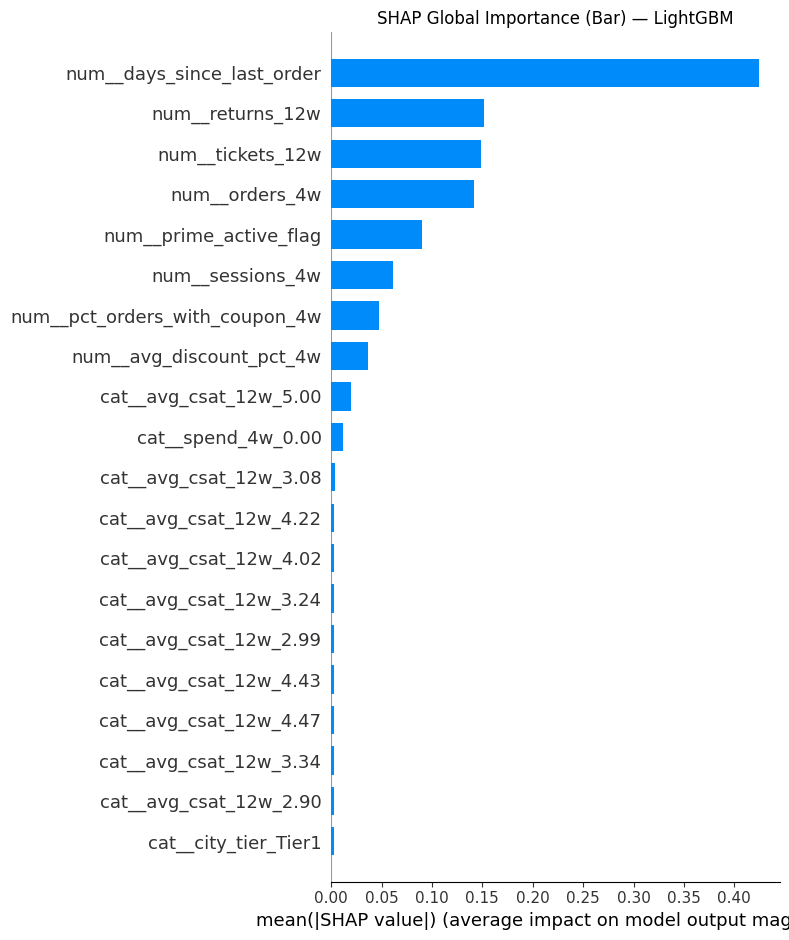

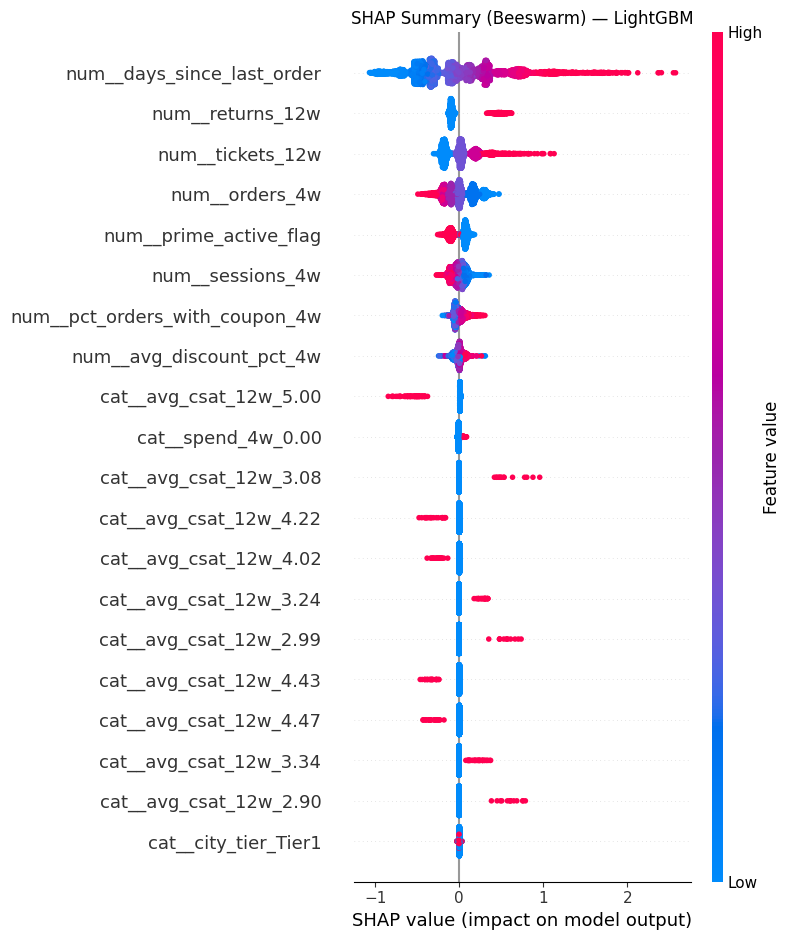

In [0]:
# (A) Bar summary: global importance
plt.figure()
shap.summary_plot(shap_vals, X_shap, plot_type="bar", show=False)
plt.title(f"SHAP Global Importance (Bar) — {SHAP_MODEL_NAME}")
plt.tight_layout()
plt.show()

# (B) Beeswarm summary: direction + magnitude
plt.figure()
shap.summary_plot(shap_vals, X_shap, show=False)
plt.title(f"SHAP Summary (Beeswarm) — {SHAP_MODEL_NAME}")
plt.tight_layout()
plt.show()

# 6) Optional: SHAP dependence plot for a top feature

<Figure size 640x480 with 0 Axes>

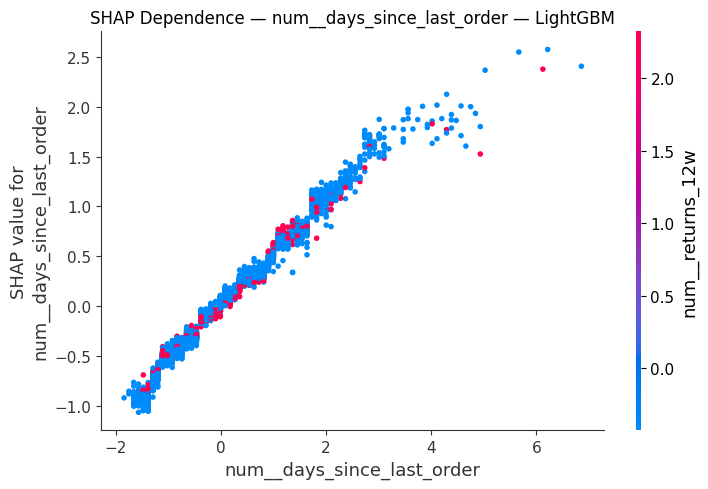

In [0]:
TOP_FEATURE = shap_importance["feature"].iloc[0]
plt.figure()
shap.dependence_plot(TOP_FEATURE, shap_vals, X_shap, show=False)
plt.title(f"SHAP Dependence — {TOP_FEATURE} — {SHAP_MODEL_NAME}")
plt.tight_layout()
plt.show()